In [1]:
import os

#add the root directory
os.chdir('../')

# Supplementary material S2.2.2: Visualize f-PV manifolds for flamelet with the heuristic and optimized parameterization

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from utils import loadFullData
from matplotlib.lines import Line2D
import logging as logging
from loader import *
from utils import *

logging.disable(logging.CRITICAL)

In [3]:
path_data = "data-files/"
filename_prefix = "Xu"
filename_suffix = "flamelet-Yuki-v2-augm"

mf_fl = pd.read_csv(path_data + f"{filename_prefix}-mf-{filename_suffix}.csv")
T_fl = pd.read_csv(path_data + f"{filename_prefix}-T-{filename_suffix}.csv")
x_fl = pd.read_csv(path_data + f"{filename_prefix}-state-space-{filename_suffix}.csv")
Sx_fl = pd.read_csv(path_data + f"{filename_prefix}-state-space_source-{filename_suffix}.csv")

In [ ]:
# Heuristic PV
PV_heuristic = x_fl["H2O"] - x_fl["H2"] - x_fl["O2"]
PV_heuristic_source = Sx_fl["H2O"] - Sx_fl["H2"] - Sx_fl["O2"]

PV_heuristic_HO2 = x_fl["H2O"] + 1000 * x_fl["HO2"]
PV_heuristic_HO2_source = Sx_fl["H2O"] + 1000 * Sx_fl["HO2"]

PV_heuristic_NO = x_fl["H2O"] + 1000 * x_fl["NO"]
PV_heuristic_NO_source = Sx_fl["H2O"] + 1000 * Sx_fl["NO"]

# Optimized PV
filename = "Xu-AE-opt_RMSprop-epo_100000-lr_0.025-date_07Apr2026-hour_16h39_Tr35a_Yuki_v2_linLog_R1_s8"

filename_metadata = filename + "_metadata.pkl"
filename_species_names = "Xu-state-space-names-flamelet-Yuki-v2.csv"
path_metadata = "C:/Users/admin/Documents/PhD-ULB/Programming/2024-PV-optimization-Xu/metadata/"

loader = loadData(filename_species_names, path_metadata, filename_metadata)
output_idx = loader.metadata["output species idx"]
idx_species_removed = loader.metadata["list idx species removed source"] if 'augm' in loader.metadata["dataset_type"] else loader.metadata["idx species removed"]
input_scaling = loader.metadata["input scaling"]
input_species_scaling = loader.metadata["input species scaling"]
input_species_bias = loader.metadata["input species bias"]
range_mf  = loader.metadata["range_mf"]
id_model = loader.metadata["Training_id"]

model_reloaded = loader.loadModel()

#code not completely correct as the input dataset contains also the log species, but code written as such that it uses the correct columns
dataset = "flamelet-Yuki-v2-augm"
input_fl, output_fl = get_dataset(path_data + f"Xu-state-space-{dataset}.csv", path_data + f"Xu-state-space_source-{dataset}.csv",
                                  path_data + f"Xu-T-{dataset}.csv", path_data + f"Xu-mf-{dataset}.csv", output_idx, idx_species_removed,
                                  input_scaling, input_species_scaling, input_species_bias, range_mf)
_, PV_optimized, PV_optimized_source = model_reloaded.get_mf_PV_PVsource(input_fl, output_fl)

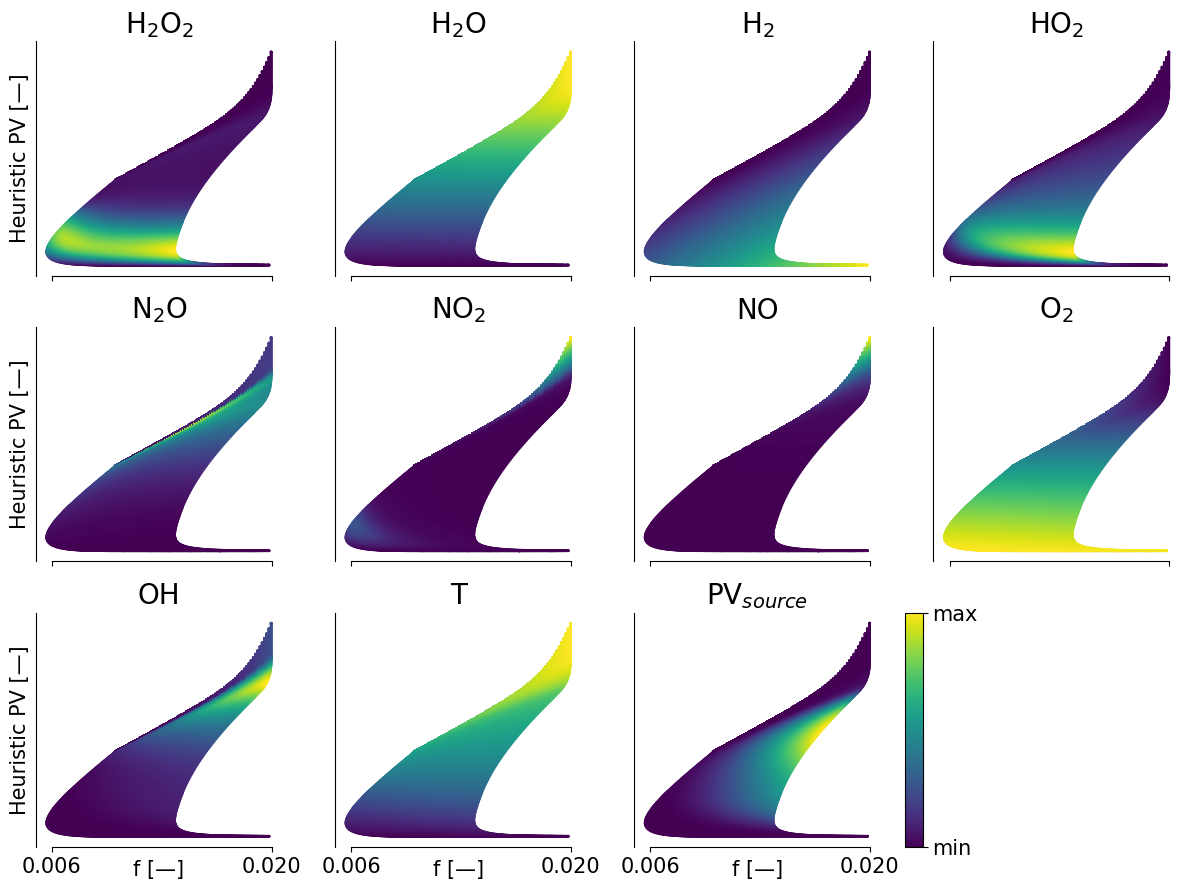

In [17]:
rows, cols = 3,4

keysSpecies = ['H2O2', 'H2O', 'H2', 'HO2', 'N2O', 'NO2', 'NO', 'O2', 'OH']
keys = ['H2O2', 'H2O', 'H2', 'HO2', 'N2O', 'NO2', 'NO', 'O2', 'OH', 'T', 'PV1']

Xu_optimized = "heu_NO"

zoom = False

save = True
pathSave = f"C:/Users/admin/Documents/PhD-ULB/Figures/2024-PV-optimization/flamelet/Yuki/f-PV manifolds/"
name = f"f-PV manifolds - flamelet Yuki v2 - coloured by QoIs - {Xu_optimized}{f' - {id_model}' if Xu_optimized.lower() == 'optimized' else ''}{' - zoom' if zoom else ''}.png"

fig, axes = plt.subplots(rows, cols, figsize=(12,9))  # Define the grid
axes = axes.flatten()
for i, key in enumerate(keys):
    ax = axes[i]

    if(Xu_optimized.lower() == "xu"):
         dataPV_fl = PV_heuristic
    elif(Xu_optimized.lower() == "heu_ho2"):
         dataPV_fl = PV_heuristic_HO2
    elif(Xu_optimized.lower() == "heu_no"):
         dataPV_fl = PV_heuristic_NO
    elif(Xu_optimized.lower() == "optimized"):
         dataPV_fl = PV_optimized
    else:
         raise ValueError("Variable 'Xu_optimized' has an invalid value; Choose either 'xu' or 'optimized'.")

    if(key in keysSpecies):
         dataColor = x_fl[key]
    elif(key  == "T"):
         dataColor = T_fl[key]
    elif(key == "PV1"):
         if(Xu_optimized.lower() == "xu"):
            dataColor = PV_heuristic_source
         elif(Xu_optimized.lower() == "heu_ho2"):
            dataColor = PV_heuristic_HO2_source
         elif(Xu_optimized.lower() == "heu_no"):
            dataColor = PV_heuristic_NO_source
         elif(Xu_optimized.lower() == "optimized"):
            dataColor = PV_optimized_source
         

    sc = ax.scatter(mf_fl, dataPV_fl, c = dataColor, cmap = "viridis", s=1)

    if zoom:
         ax.set_xlim([0, 0.05])

    if(i>len(keys)-cols):
        if zoom:
               ax.set_xticks([0, 0.05])
        else:
               ax.set_xticks([0.006, 0.020])
        ax.tick_params(axis="x", labelsize=15) 
        ax.set_xlabel("f [\u2014]", fontsize = 15, labelpad = -12)
    else:
        ax.set_xticks([0.006, 0.020])
        ax.set_xticklabels([])
    if(i%cols == 0):
        ax.set_ylabel(f'{"Optimized" if Xu_optimized.lower() == "optimized" else "Heuristic"} PV [\u2014]', fontsize = 15)
    ax.set_yticks([])

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines["bottom"].set_bounds(0.006, 0.020)
    
    key = key.replace("2", "$_{2}$").replace("1", "$_{source}$")

    ax.set_title(rf"{key}", fontsize=20)


for j in range(len(keys), len(axes)): #disables axes of plots not used
    axes[j].axis("off")

handles, labels = axes[0].get_legend_handles_labels()

plt.tight_layout()
pos = axes[10].get_position()

# Define colorbar axis manually
cbar_width = 0.015   # thin bar
gap = 0.02           # small gap from subplot

cax = fig.add_axes([
    pos.x1 + gap,    # x start (right of subplot 11)
    pos.y0,          # same bottom
    cbar_width,      # width
    pos.height       # same height
])
cbar = fig.colorbar(sc, cax=cax, orientation="vertical")

vmin, vmax = sc.get_clim()

# Set ticks at the extrema
cbar.set_ticks([vmin, vmax])

# Replace numeric tick labels
cbar.set_ticklabels(["min", "max"])
cbar.ax.tick_params(labelsize=15)

if(save):
        plt.savefig(f"{pathSave}{name}", dpi = 300, bbox_inches="tight")
plt.show()